# Tutorial 3 - From generation to transport dynamics

**Course:** Power Electronics Devices and Components  
**Lecture linkage:** carrier generation, recombination, diffusion, drift, and continuity equation

## Why this tutorial matters
Students often learn **generation**, **recombination**, **diffusion**, **drift**, and the **continuity equation** in separate lecture blocks. In a real semiconductor device, however, these processes act **simultaneously**. This tutorial is designed to make that coupling visible.

The notebook follows one excess-carrier packet and shows how:
- **diffusion** spreads the packet,
- **drift** shifts the packet in space,
- **recombination** reduces its amplitude and total carrier number.

This is one of the clearest ways to help students understand what the continuity equation actually means physically.

## Governing equation used in this notebook
We model the excess-electron concentration \(\Delta n(x,t)\) in one dimension using the simplified advection-diffusion-recombination equation

\[
\frac{\partial \Delta n}{\partial t}
=
D_n\frac{\partial^2 \Delta n}{\partial x^2}
-
v_d\frac{\partial \Delta n}{\partial x}
-
\frac{\Delta n}{\tau}
\]

where:
- \(D_n\) = electron diffusion coefficient,
- \(v_d = \mu_n E\) = drift velocity,
- \(\mu_n\) = electron mobility,
- \(E\) = applied electric field,
- \(\tau\) = carrier lifetime.

## Fixed values for this tutorial
Use the following values unless a question explicitly asks you to vary them:

- Device length: \(L = 120\,\mu\mathrm{m}\)
- Number of spatial grid points: \(N_x = 241\)
- Initial packet center: \(x_0 = 36\,\mu\mathrm{m}\)
- Initial packet width (Gaussian standard deviation): \(\sigma_0 = 7\,\mu\mathrm{m}\)
- Initial peak excess concentration: \(\Delta n_0 = 1\times 10^{15}\,\mathrm{cm^{-3}}\)
- Electron diffusion coefficient: \(D_n = 20\,\mathrm{cm^2/s}\)
- Electron mobility: \(\mu_n = 1350\,\mathrm{cm^2/(V\cdot s)}\)
- Total simulation time: \(0.25\,\mu\mathrm{s}\)
- Snapshot times: \(t = [0,\;0.05,\;0.10,\;0.20,\;0.25]\,\mu\mathrm{s}\)

### Part-specific values
- **Part A:** \(E = 0\,\mathrm{V/cm}\), \(\tau = 3\,\mu\mathrm{s}\)
- **Part B:** \(E = 5\,\mathrm{V/cm}\), \(\tau = 3\,\mu\mathrm{s}\)
- **Part C:** \(E = 5\,\mathrm{V/cm}\), \(\tau = [0.5,\;3,\;10]\,\mu\mathrm{s}\)

## Workflow in this notebook
1. define the domain and initial excess-carrier packet  
2. simulate **diffusion + recombination** without drift  
3. simulate **drift + diffusion + recombination** and compare with Part A  
4. vary the **carrier lifetime** and observe how recombination changes the result  
5. connect the plots back to the continuity-equation language

## Student tasks

### Part A - Diffusion and recombination without drift
Use the fixed values above with:
- \(E = 0\,\mathrm{V/cm}\)
- \(\tau = 3\,\mu\mathrm{s}\)

Tasks:
1. Plot the excess-carrier profiles at \(t = 0,\;0.05,\;0.10,\;0.20,\;0.25\,\mu\mathrm{s}\).
2. Plot the **peak excess concentration** versus time.
3. Explain which physical mechanism broadens the packet and which one reduces its amplitude.

### Part B - Add drift and compare with Part A
Use the same values as Part A, but now set:
- \(E = 5\,\mathrm{V/cm}\)
- \(\mu_n = 1350\,\mathrm{cm^2/(V\cdot s)}\)

Tasks:
1. Plot the excess-carrier profiles at the same five snapshot times.
2. Plot the **packet center position** versus time for both:
   - \(E = 0\,\mathrm{V/cm}\)
   - \(E = 5\,\mathrm{V/cm}\)
3. Explain which mechanism causes translation, which causes spreading, and which causes decay.
4. Estimate the drift velocity from the plot and compare it with \(v_d = \mu_n E\).

### Part C - Lifetime sweep
Use the same geometry and initial packet as before with:
- \(E = 5\,\mathrm{V/cm}\)
- \(\tau = 0.5,\;3,\;10\,\mu\mathrm{s}\)

Tasks:
1. Plot the **total excess carrier number** versus time for all three lifetimes.
2. Plot the **peak excess concentration** versus time for all three lifetimes.
3. State which lifetime allows the transport effects to remain visible for longer.
4. Explain why short lifetime can hide transport effects even when drift and diffusion are present.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Fixed values for the tutorial
# ---------------------------------------------------------------------
L_um = 120.0
Nx = 241
x0_um = 36.0
sigma0_um = 7.0
delta_n0 = 1e15           # cm^-3
D_n = 20.0                # cm^2/s
mu_n = 1350.0             # cm^2/(V s)
total_time_us = 0.25
snapshot_times_us = [0.00, 0.05, 0.10, 0.20, 0.25]

# Unit conversions to cm and s
L = L_um * 1e-4
x0 = x0_um * 1e-4
sigma0 = sigma0_um * 1e-4
total_time = total_time_us * 1e-6

# Spatial grid
x = np.linspace(0.0, L, Nx)
dx = x[1] - x[0]

print("Fixed values used in this tutorial:")
print(f"  Device length L = {L_um:.1f} um")
print(f"  Spatial grid points Nx = {Nx:d}")
print(f"  Initial packet center x0 = {x0_um:.1f} um")
print(f"  Initial packet width sigma0 = {sigma0_um:.1f} um")
print(f"  Initial peak excess concentration = {delta_n0:.2e} cm^-3")
print(f"  Diffusion coefficient D_n = {D_n:.1f} cm^2/s")
print(f"  Electron mobility mu_n = {mu_n:.1f} cm^2/(V s)")
print(f"  Total simulation time = {total_time_us:.2f} us")
print(f"  Snapshot times (us) = {snapshot_times_us}")

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def initial_packet(x_cm, x0_cm, sigma_cm, amplitude_cm3):
    return amplitude_cm3 * np.exp(-((x_cm - x0_cm) ** 2) / (2.0 * sigma_cm**2))

def stable_time_step(dx_cm, D_cm2_per_s, v_cm_per_s):
    dt_diff = 0.45 * dx_cm**2 / (2.0 * D_cm2_per_s)
    if abs(v_cm_per_s) > 0:
        dt_adv = 0.80 * dx_cm / abs(v_cm_per_s)
    else:
        dt_adv = np.inf
    return min(dt_diff, dt_adv)

def simulate_packet(
    x_cm,
    D_cm2_per_s,
    tau_s,
    mu_cm2_per_Vs,
    E_V_per_cm,
    amplitude_cm3,
    x0_cm,
    sigma_cm,
    total_time_s,
    snapshot_times_us
):
    v_drift = mu_cm2_per_Vs * E_V_per_cm
    dt_stable = stable_time_step(x_cm[1] - x_cm[0], D_cm2_per_s, v_drift)
    Nt = int(np.ceil(total_time_s / dt_stable))
    dt = total_time_s / Nt

    u = initial_packet(x_cm, x0_cm, sigma_cm, amplitude_cm3)

    snapshot_steps = sorted(set(
        int(np.clip(np.round((t_us * 1e-6) / dt), 0, Nt)) for t_us in snapshot_times_us
    ))
    snapshots = {}

    times = np.arange(Nt + 1) * dt
    centres = np.zeros(Nt + 1)
    totals = np.zeros(Nt + 1)
    peaks = np.zeros(Nt + 1)
    widths = np.zeros(Nt + 1)

    def record(step, profile):
        total = np.trapezoid(profile, x_cm)
        centre = np.trapezoid(x_cm * profile, x_cm) / total
        variance = np.trapezoid(((x_cm - centre) ** 2) * profile, x_cm) / total
        centres[step] = centre
        totals[step] = total
        peaks[step] = np.max(profile)
        widths[step] = np.sqrt(max(variance, 0.0))

    record(0, u)
    if 0 in snapshot_steps:
        snapshots[0] = u.copy()

    for step in range(1, Nt + 1):
        lap = np.zeros_like(u)
        lap[1:-1] = (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (x_cm[1] - x_cm[0])**2

        grad = np.zeros_like(u)
        if v_drift >= 0:
            grad[1:] = (u[1:] - u[:-1]) / (x_cm[1] - x_cm[0])
            grad[0] = grad[1]
        else:
            grad[:-1] = (u[1:] - u[:-1]) / (x_cm[1] - x_cm[0])
            grad[-1] = grad[-2]

        u_new = u + dt * (D_cm2_per_s * lap - v_drift * grad - u / tau_s)

        # Zero-gradient boundaries
        u_new[0] = u_new[1]
        u_new[-1] = u_new[-2]

        # Prevent tiny negative values from numerical round-off
        u_new = np.maximum(u_new, 0.0)

        u = u_new
        record(step, u)

        if step in snapshot_steps:
            snapshots[step] = u.copy()

    return {
        "dt": dt,
        "Nt": Nt,
        "times": times,
        "snapshots": snapshots,
        "snapshot_steps": snapshot_steps,
        "centres": centres,
        "totals": totals,
        "peaks": peaks,
        "widths": widths,
        "v_drift": v_drift,
    }

def label_from_step(step, dt_s):
    return f"t = {step * dt_s * 1e6:.2f} us"


Fixed values used in this tutorial:
  Device length L = 120.0 um
  Spatial grid points Nx = 241
  Initial packet center x0 = 36.0 um
  Initial packet width sigma0 = 7.0 um
  Initial peak excess concentration = 1.00e+15 cm^-3
  Diffusion coefficient D_n = 20.0 cm^2/s
  Electron mobility mu_n = 1350.0 cm^2/(V s)
  Total simulation time = 0.25 us
  Snapshot times (us) = [0.0, 0.05, 0.1, 0.2, 0.25]


--- Part A settings ---
Electric field E = 0.0 V/cm
Lifetime tau = 3.0 us
Stable time step dt = 0.0281 ns
Number of time steps Nt = 8889


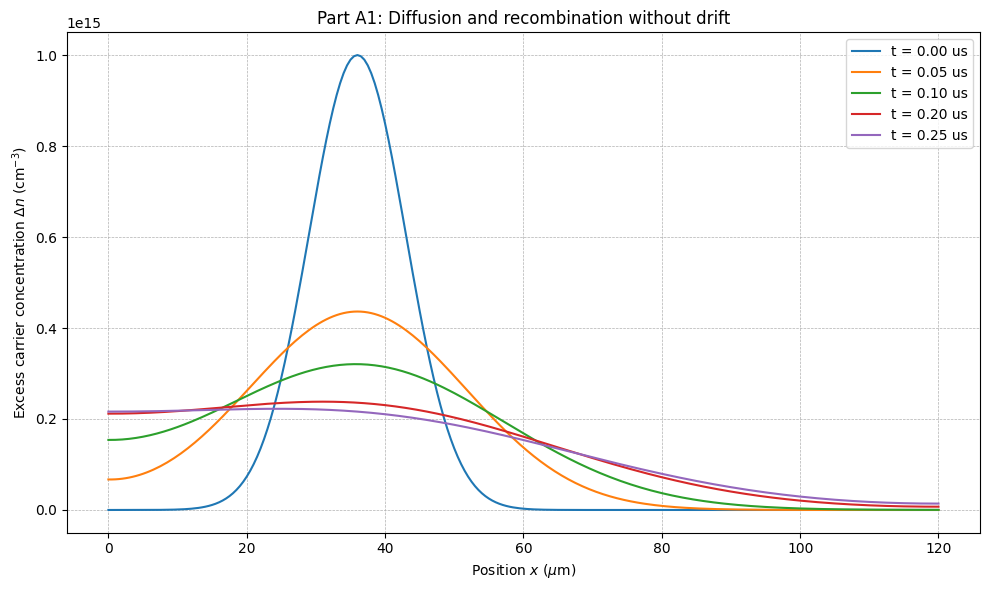

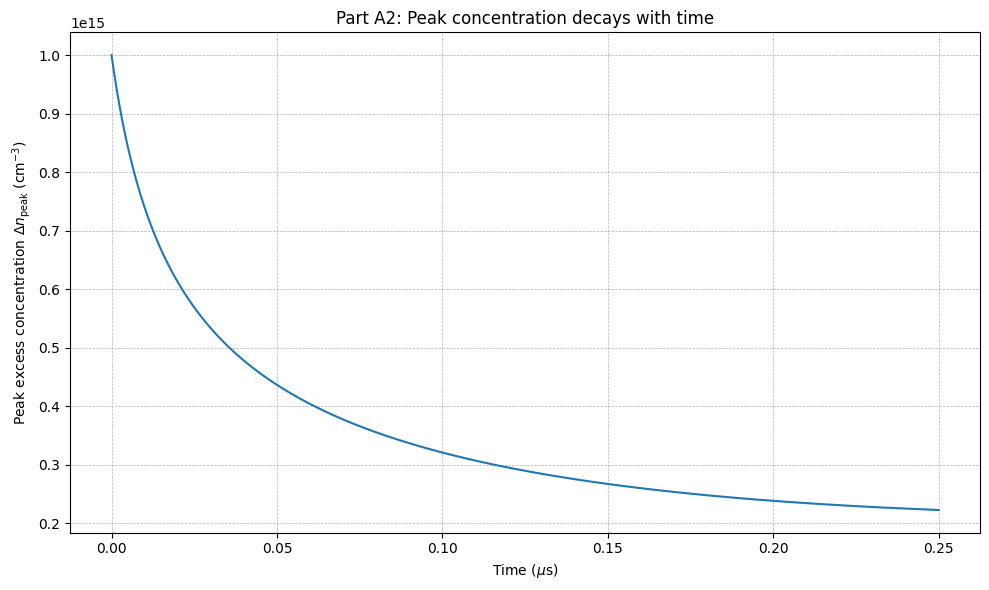

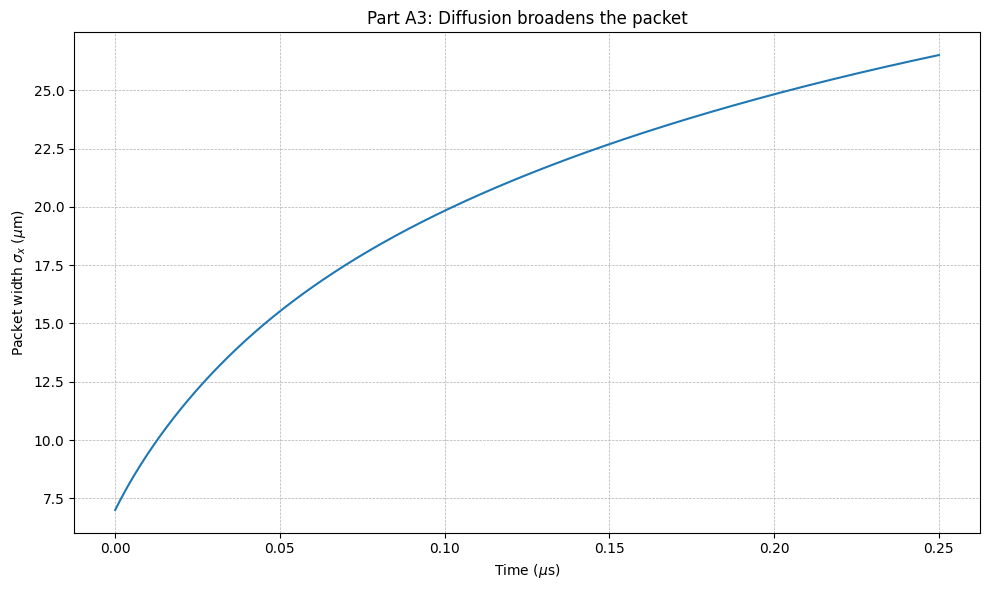

In [2]:

# ---------------------------------------------------------------------
# Part A - Diffusion + recombination only (no drift)
# ---------------------------------------------------------------------
E_A = 0.0
tau_A = 3.0e-6

result_A = simulate_packet(
    x_cm=x,
    D_cm2_per_s=D_n,
    tau_s=tau_A,
    mu_cm2_per_Vs=mu_n,
    E_V_per_cm=E_A,
    amplitude_cm3=delta_n0,
    x0_cm=x0,
    sigma_cm=sigma0,
    total_time_s=total_time,
    snapshot_times_us=snapshot_times_us,
)

print("--- Part A settings ---")
print(f"Electric field E = {E_A:.1f} V/cm")
print(f"Lifetime tau = {tau_A*1e6:.1f} us")
print(f"Stable time step dt = {result_A['dt']*1e9:.4f} ns")
print(f"Number of time steps Nt = {result_A['Nt']}")

plt.figure(figsize=(10, 6))
for step in result_A["snapshot_steps"]:
    plt.plot(x * 1e4, result_A["snapshots"][step], label=label_from_step(step, result_A["dt"]))
plt.xlabel(r'Position $x$ ($\mu$m)')
plt.ylabel(r'Excess carrier concentration $\Delta n$ (cm$^{-3}$)')
plt.title('Part A1: Diffusion and recombination without drift')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(result_A["times"] * 1e6, result_A["peaks"])
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Peak excess concentration $\Delta n_\mathrm{peak}$ (cm$^{-3}$)')
plt.title('Part A2: Peak concentration decays with time')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(result_A["times"] * 1e6, result_A["widths"] * 1e4)
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Packet width $\sigma_x$ ($\mu$m)')
plt.title('Part A3: Diffusion broadens the packet')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


--- Part B settings ---
Electric field E = 5.0 V/cm
Lifetime tau = 3.0 us
Drift velocity v_d = mu_n * E = 6.750e+03 cm/s
Stable time step dt = 0.0281 ns
Number of time steps Nt = 8889


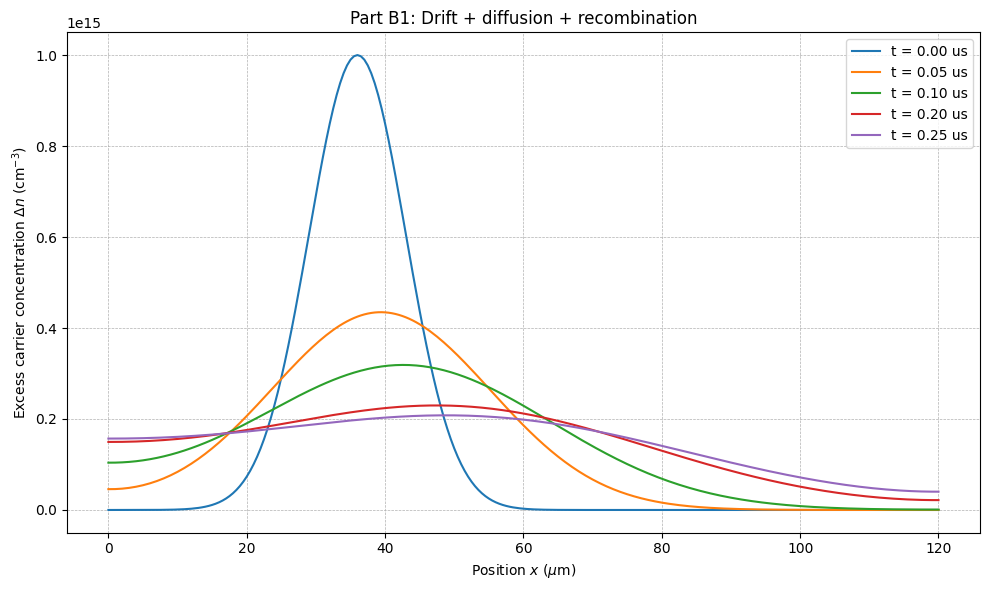

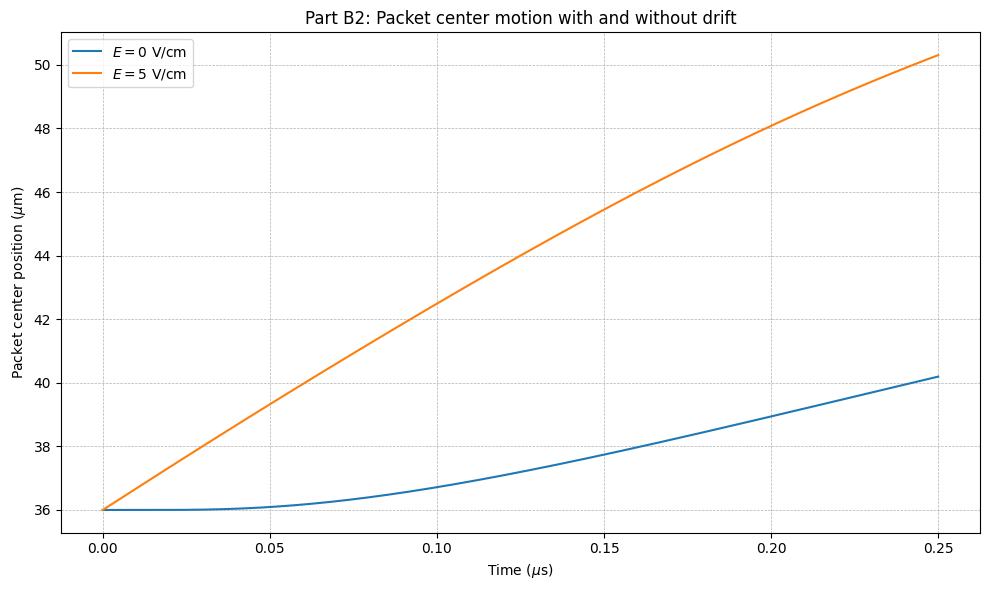

Estimated drift velocity from center motion = 5.724e+03 cm/s
Theoretical drift velocity mu_n * E         = 6.750e+03 cm/s


In [3]:

# ---------------------------------------------------------------------
# Part B - Add drift and compare with Part A
# ---------------------------------------------------------------------
E_B = 5.0
tau_B = 3.0e-6

result_B = simulate_packet(
    x_cm=x,
    D_cm2_per_s=D_n,
    tau_s=tau_B,
    mu_cm2_per_Vs=mu_n,
    E_V_per_cm=E_B,
    amplitude_cm3=delta_n0,
    x0_cm=x0,
    sigma_cm=sigma0,
    total_time_s=total_time,
    snapshot_times_us=snapshot_times_us,
)

print("--- Part B settings ---")
print(f"Electric field E = {E_B:.1f} V/cm")
print(f"Lifetime tau = {tau_B*1e6:.1f} us")
print(f"Drift velocity v_d = mu_n * E = {result_B['v_drift']:.3e} cm/s")
print(f"Stable time step dt = {result_B['dt']*1e9:.4f} ns")
print(f"Number of time steps Nt = {result_B['Nt']}")

plt.figure(figsize=(10, 6))
for step in result_B["snapshot_steps"]:
    plt.plot(x * 1e4, result_B["snapshots"][step], label=label_from_step(step, result_B["dt"]))
plt.xlabel(r'Position $x$ ($\mu$m)')
plt.ylabel(r'Excess carrier concentration $\Delta n$ (cm$^{-3}$)')
plt.title('Part B1: Drift + diffusion + recombination')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(result_A["times"] * 1e6, result_A["centres"] * 1e4, label=r'$E=0$ V/cm')
plt.plot(result_B["times"] * 1e6, result_B["centres"] * 1e4, label=r'$E=5$ V/cm')
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Packet center position ($\mu$m)')
plt.title('Part B2: Packet center motion with and without drift')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

estimated_velocity = (result_B["centres"][-1] - result_B["centres"][0]) / (result_B["times"][-1] - result_B["times"][0])
print(f"Estimated drift velocity from center motion = {estimated_velocity:.3e} cm/s")
print(f"Theoretical drift velocity mu_n * E         = {result_B['v_drift']:.3e} cm/s")


--- Part C settings ---
Electric field E = 5.0 V/cm
Lifetimes (us) = [0.5, 3.0, 10.0]


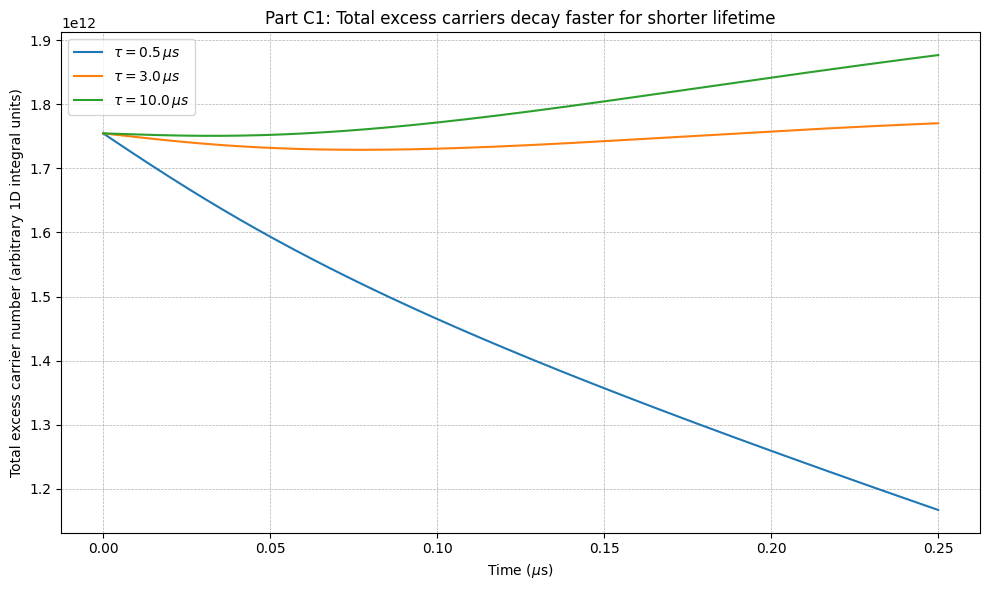

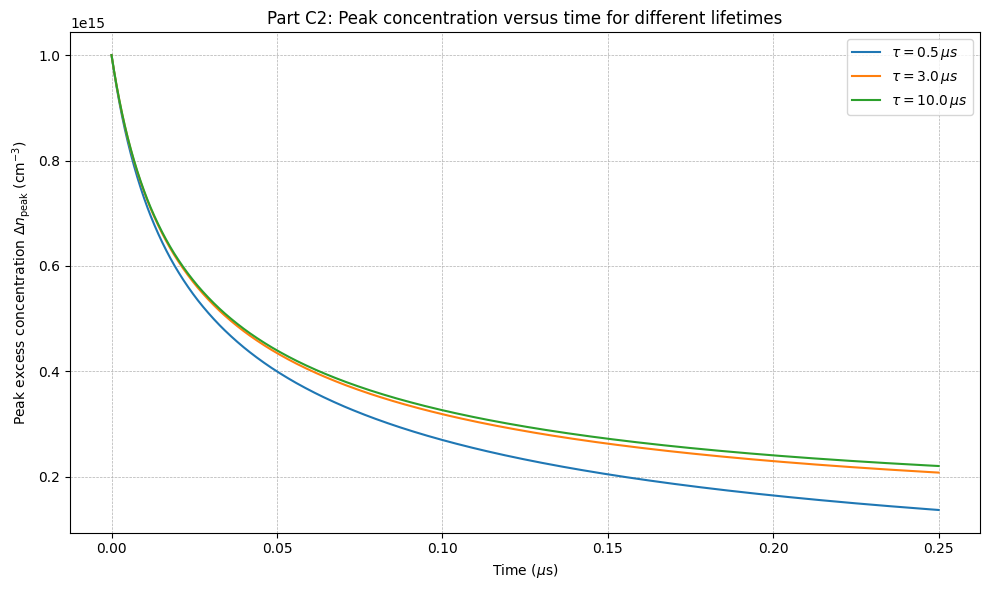

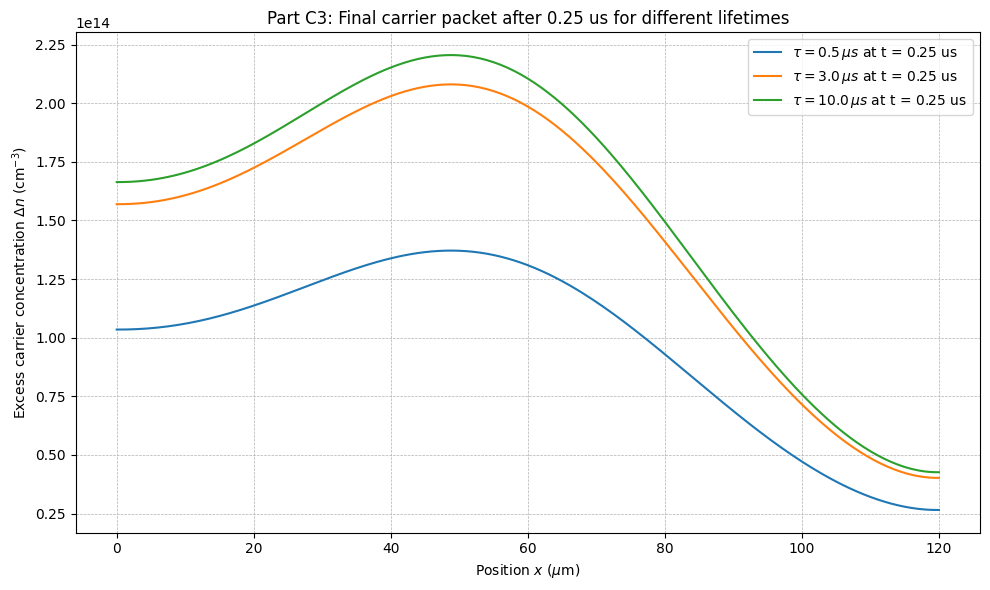

In [4]:

# ---------------------------------------------------------------------
# Part C - Lifetime sweep at fixed drift field
# ---------------------------------------------------------------------
E_C = 5.0
tau_list_us = [0.5, 3.0, 10.0]
tau_list_s = [tau * 1e-6 for tau in tau_list_us]

results_C = {}
for tau_us, tau_s in zip(tau_list_us, tau_list_s):
    results_C[tau_us] = simulate_packet(
        x_cm=x,
        D_cm2_per_s=D_n,
        tau_s=tau_s,
        mu_cm2_per_Vs=mu_n,
        E_V_per_cm=E_C,
        amplitude_cm3=delta_n0,
        x0_cm=x0,
        sigma_cm=sigma0,
        total_time_s=total_time,
        snapshot_times_us=snapshot_times_us,
    )

print("--- Part C settings ---")
print(f"Electric field E = {E_C:.1f} V/cm")
print(f"Lifetimes (us) = {tau_list_us}")

plt.figure(figsize=(10, 6))
for tau_us in tau_list_us:
    plt.plot(
        results_C[tau_us]["times"] * 1e6,
        results_C[tau_us]["totals"],
        label=fr'$\tau={tau_us:.1f}\,\mu s$'
    )
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Total excess carrier number (arbitrary 1D integral units)')
plt.title('Part C1: Total excess carriers decay faster for shorter lifetime')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for tau_us in tau_list_us:
    plt.plot(
        results_C[tau_us]["times"] * 1e6,
        results_C[tau_us]["peaks"],
        label=fr'$\tau={tau_us:.1f}\,\mu s$'
    )
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Peak excess concentration $\Delta n_\mathrm{peak}$ (cm$^{-3}$)')
plt.title('Part C2: Peak concentration versus time for different lifetimes')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for tau_us in tau_list_us:
    final_step = max(results_C[tau_us]["snapshot_steps"])
    plt.plot(
        x * 1e4,
        results_C[tau_us]["snapshots"][final_step],
        label=fr'$\tau={tau_us:.1f}\,\mu s$ at {label_from_step(final_step, results_C[tau_us]["dt"])}'
    )
plt.xlabel(r'Position $x$ ($\mu$m)')
plt.ylabel(r'Excess carrier concentration $\Delta n$ (cm$^{-3}$)')
plt.title('Part C3: Final carrier packet after 0.25 us for different lifetimes')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Reflection and discussion questions
1. In Part A, why does the packet become wider even though no electric field is applied?
2. Why does the peak concentration decrease faster than the packet width increases?
3. In Part B, why does the packet center move only when an electric field is present?
4. In Part C, why does a shorter lifetime make the transport effects harder to observe experimentally?
5. Which practical devices are strongly affected by the combined action of drift, diffusion, and recombination?

## Suggested extensions for students
1. Repeat Part B with \(E = 1,\;5,\;10\,\mathrm{V/cm}\) and compare the extracted drift velocity with \(v_d = \mu_n E\).
2. Repeat Part A with \(D_n = 5,\;20,\;50\,\mathrm{cm^2/s}\) and compare the packet broadening rate.
3. Replace the initial Gaussian packet by two packets placed at different positions and study how they evolve.
4. Add a constant generation term \(G\) to the equation and explore when generation balances recombination.